#RACCOLTA DATI

In [1063]:
import pandas as pd

In [1064]:
url = "https://raw.githubusercontent.com/Profession-AI/progetti-ml/refs/heads/main/Analizza%20il%20sentiment%20delle%20notizie%20finanziarie%20su%20un%20titolo/Full_FinanceTech_Corp_Tweets_Dataset.csv"

In [1065]:
from nltk.sem.drt import DrtFunctionVariableExpression
df = pd.read_csv(url)

df

,tweet,sentiment
0,FinanceTech Corp highlight a drop in stock val...,negative
1,The team at FinanceTech announce record-breaki...,positive
2,Investors in FinanceTech are thrilled with str...,positive
3,The team at FinanceTech are disappointed by de...,negative
4,FinanceTech Corp announce positive customer fe...,positive
...,...,...
995,FinanceTech's CEO report market expansion. #Fi...,positive
996,FinanceTech Corp are disappointed by a drop in...,negative
997,Investors in FinanceTech highlight market cont...,negative
998,FinanceTech Corp celebrate market expansion. #...,positive


##1. Analizziamo il dataset

Analizziamo il contenuto del dataset

In [1066]:
print(f"Info dataset : {df.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet      1000 non-null   object
 1   sentiment  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB
Info dataset : None


**Interpretazione**:

Dall'output precedente possiamo concludere che:
1. Il dataset ha 1000 righe;
2. Il dataset ha 2 colonne: tweet e sentiment;
3. Non sono presenti valori nulli in nessuna delle due colonne;
4. Il tipo di dato conenuto in entrambe le colonne sono stringhe (object)

### Controllo delle feutures

In [1067]:
tweets_df = df["tweet"]
sentiments_df = df["sentiment"]

Controlliamo i valori unici presenti nella colonna "sentiment"

In [1068]:
sentiment_df_list = list(sentiments_df.unique())

sentiment_df_list

['negative', 'positive']

Controlliamo se sono presenti duplicati nella colonna tweet

In [1069]:
#Definiamo una funzione per il check dei duplicati
def check_duplicati(unique_values,dataset):
  if len(unique_values) == len(dataset):
    print("All'interno della colonna tweet NON sono presenti duplicati")
  else:
    print("All'interno della colonna tweet sono presenti duplicati")


In [1070]:
tweets_df_list = list(tweets_df.unique())

check_duplicati(df,tweets_df_list)

All'interno della colonna tweet NON sono presenti duplicati


###Verifica dell'equilibrio del dataset


Definiamo una funzione che ci permette di verificare se il dataset è equilibrato rispetto ad una colonna. </br>
La funzione prende come argomenti:
1. col = la colonna del dataset;
2. tol = la soglia di tolleranza espressa in decimali per cui possiamo definire il dataset ancora "equilibrato".
3. val = i valori effettivi delle feutures (es. positive, negative, ecc.)

In [1071]:
import numpy as np
def eda(col,tol,val):

  print(f"""Lunghezza colonna : {len(col)}
Numero features : {len(val)} \n""")

  #conta il numero di ogni val
  count =[]
  for string in val:
    somma = int((col == string).sum())
    count.append(somma)
    print(f"{string} : {somma}")


  #calcolo delle differenze tra ogni val
  n_val = len(val)
  rif_value = len(col)/n_val

  differenze = []
  for i in range(0,len(count)):
    differenza = abs(count[i]-rif_value)
    differenze.append(differenza)


  tollerance = rif_value*tol
  vett_zero = list(np.zeros(len(differenze)))
  n = 0

  print(f"""\nValore medio : {rif_value: .2f}
Tollerance = +-{tollerance: .2f}
Intervallo di tolleranza : [{(rif_value+tollerance): .2f} :{(rif_value-tollerance): .2f} ]
Numero di Features che superano la soglia di tolleranza : {n} \n""")

  #print del risultato finale
  if vett_zero == differenze:
    print("\nLa colonna è perfettamente equlibrata")
  elif vett_zero != differenze:
    for k in differenze:
      if abs(k) > tollerance:
        n = n+1
    if n == 0:
      print("\nLa colonna è pressocché equilibrata")
    else:
      print("\nLa colonna non è equilibrata")

In [1072]:
#Effettuiano un EDA per la colonna sentiment
eda(sentiments_df,0,sentiment_df_list)

Lunghezza colonna : 1000
Numero features : 2 

negative : 500
positive : 500

Valore medio :  500.00
Tollerance = +- 0.00
Intervallo di tolleranza : [ 500.00 : 500.00 ]
Numero di Features che superano la soglia di tolleranza : 0 


La colonna è perfettamente equlibrata


##2. Pre Processing

###Data Cleaning

Innanzitutto, eliminiamo le parole seguite dall'hashtag dalla colonna tweet e inseriamole all'interno di una nuova colonna denominata "category"

In [1073]:
dataset = df.copy()

#creiamo la colonna category utilizzando le parole che seguono #
dataset["category"] = dataset["tweet"].str.extract(r"#(\w+)")

#Eliminiamo gli # e le parole che lo seguono dalla colonna tweet
dataset["tweet"] = dataset["tweet"].str.replace(r"\s*#\w+", "", regex=True)

dataset

,tweet,sentiment,category
0,FinanceTech Corp highlight a drop in stock value.,negative,TechNews
1,The team at FinanceTech announce record-breaki...,positive,TechNews
2,Investors in FinanceTech are thrilled with str...,positive,investing
3,The team at FinanceTech are disappointed by de...,negative,stocks
4,FinanceTech Corp announce positive customer fe...,positive,finance
...,...,...,...
995,FinanceTech's CEO report market expansion.,positive,FinTech
996,FinanceTech Corp are disappointed by a drop in...,negative,stocks
997,Investors in FinanceTech highlight market cont...,negative,markets
998,FinanceTech Corp celebrate market expansion.,positive,FinTech


####Analisi del nuovo dataset

In [1074]:
print("Info dataset :\n")
dataset.info()

Info dataset :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet      1000 non-null   object
 1   sentiment  1000 non-null   object
 2   category   1000 non-null   object
dtypes: object(3)
memory usage: 23.6+ KB


**Interpretazione**:

Dall'output precedente possiamo concludere che:
1. Il dataset ha 1000 righe;
2. Il dataset ha 3 colonne: tweet, sentiment e category;
3. Non sono presenti valori nulli in nessuna delle tre colonne;
4. Le feutures di entrambe le colonne sono stringhe (object)

In altre parole, rispetto al dataset precedente abbiamo solo una colonna in più che rappresenta la categoria a cui è associata la frase corrispondente

#####Controllo delle features

In [1075]:
tweets_dataset = dataset["tweet"]

Controlliamo se sono presenti duplicati all'interno della colonna tweets

In [1076]:
tweets_list = list(tweets_dataset.unique())

check_duplicati(dataset,tweets_list)

All'interno della colonna tweet sono presenti duplicati


Rimuoviamo i duplicati e ricontrolliamo il dataset

In [1077]:
dataset = dataset.drop_duplicates(subset=["tweet"], keep="first").reset_index(drop=True)

dataset

,tweet,sentiment,category
0,FinanceTech Corp highlight a drop in stock value.,negative,TechNews
1,The team at FinanceTech announce record-breaki...,positive,TechNews
2,Investors in FinanceTech are thrilled with str...,positive,investing
3,The team at FinanceTech are disappointed by de...,negative,stocks
4,FinanceTech Corp announce positive customer fe...,positive,finance
...,...,...,...
409,FinanceTech shareholders are thrilled with a s...,positive,finance
410,FinanceTech Corp highlight negative investor s...,negative,stocks
411,Market analysts report positive customer feedb...,positive,TechNews
412,FinanceTech's CEO highlight a surge in stock p...,positive,investing


In [1078]:
print("Info dataset :\n")
dataset.info()

Info dataset :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   tweet      414 non-null    object
 1   sentiment  414 non-null    object
 2   category   414 non-null    object
dtypes: object(3)
memory usage: 9.8+ KB


**Interpretazione**:

Dall'output precedente possiamo concludere che:
1. Il dataset ha 414 righe;
2. Il dataset ha 3 colonne: tweet, sentiment e category;
3. Non sono presenti valori nulli in nessuna delle tre colonne;
4. Le feutures di entrambe le colonne sono stringhe (object)

Si noti che con l'eliminazione degli hashtag dalle frasi sono emerse numerose frasi identiche tra loro.

I duplicati sono stati eliminati al fine di evitare che il modello di sentiment analysis possa essere caratterizzato da data leakege.

#####Effettuiamo un EDA del dataset rispetto alla colonna sentiment

In [1079]:
sentiments = dataset["sentiment"]

In [1080]:
sentiment_list = list(sentiments.unique())

In [1081]:
eda(sentiments,0,sentiment_list)

Lunghezza colonna : 414
Numero features : 2 

negative : 207
positive : 207

Valore medio :  207.00
Tollerance = +- 0.00
Intervallo di tolleranza : [ 207.00 : 207.00 ]
Numero di Features che superano la soglia di tolleranza : 0 


La colonna è perfettamente equlibrata


#####Visualizziamo i valori unici della colonna categoria

In [1082]:
category = dataset["category"]

list(category.unique())

['TechNews', 'investing', 'stocks', 'finance', 'FinTech', 'markets']

Utilizziamo la funzione studiata per effettuare il Data Cleaning

In [1083]:
#importiamo tutti i metodi necessari per il preprocessing del dataset
import string
import spacy
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
import re

#istanziamo i metodi scegliendo quelli necessari per il nostro dataset
english_stopwords = stopwords.words("english")
nlp = spacy.load("en_core_web_sm")
punctuation = set(string.punctuation)

def data_cleaner(dataset):
  dataset_to_return = []
  for sentence in dataset:
    sentence = sentence.lower()
    for c in string.punctuation:
      sentence = sentence.replace(c, " ")
    document = nlp(sentence)
    sentence = " ".join(token.lemma_ for token in document)
    sentence = " ".join(word for word in sentence.split() if word not in english_stopwords)
    sentence = re.sub("\d", "", sentence)
    dataset_to_return.append(sentence)

  return dataset_to_return

<>:23: SyntaxWarning: invalid escape sequence '\d'
<>:23: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1328/1701212026.py:23: SyntaxWarning: invalid escape sequence '\d'
  sentence = re.sub("\d", "", sentence)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [1084]:
tweets = dataset["tweet"]

In [1085]:
#puliamo il dataset tweets
tweets_cleaned = data_cleaner(tweets)

In [1086]:
#Visualizziamo il risultato ottenuto
tweets_cleaned

['financetech corp highlight drop stock value',
 'team financetech announce record break profit',
 'investor financetech thrill strong quarterly earning',
 'team financetech disappoint decline profit',
 'financetech corp announce positive customer feedback',
 'financetech shareholder face decline profit',
 'team financetech announce strong quarterly earning',
 'financetech corp highlight market contraction',
 'financetech shareholder face negative investor sentiment',
 'investor financetech announce record break profit',
 'investor financetech highlight negative investor sentiment',
 'team financetech announce negative investor sentiment',
 'market analyst enjoy record break profit',
 'investor financetech report market expansion',
 'financetech corp highlight positive customer feedback',
 'market analyst disappoint drop stock value',
 'team financetech struggle negative investor sentiment',
 'team financetech highlight decline profit',
 'financetech corp report market expansion',
 'ma

In [1087]:
#Verifichiamo che la lunghezza corrisponda a quella della colonna originaria
if len(tweets_cleaned)==len(tweets):
  print(f"Le lunghezze corrispondono: {len(tweets_cleaned)}, {len(tweets)}")
else:
  print(f"ERRORE. Le lunghezze non corrispondono: {len(tweets_cleaned)}, {len(tweets)}")

Le lunghezze corrispondono: 414, 414


In [1088]:
#Verifichiamo la presenza di duplicati dopo il processo di data cleaning
tweets_cleaned_unique = pd.Series(tweets_cleaned).unique()

check_duplicati(tweets_cleaned,tweets_cleaned_unique)

All'interno della colonna tweet NON sono presenti duplicati


###Vettorizzazione (BOW)

Effettuiamo il Bag Of Word utilizzando il metodo IF-IDF

In [1089]:
#importiamo i metodi per effettuare lo split del dataset ed il TF-IDF
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [1090]:
#splittiamo il dataset pulito utilizzando train_test_split
x, x_test, y, y_test = train_test_split(tweets_cleaned, sentiments, test_size = 0.2, random_state = 46)

In [1091]:
print(len(x),len(x_test),len(y),len(y_test))
print(type(x),type(x_test),type(y),type(y_test))

331 83 331 83
<class 'list'> <class 'list'> <class 'pandas.core.series.Series'> <class 'pandas.core.series.Series'>


In [1092]:
#Utilizziamo la funzione studiata per applicare il metodo TF-IDF
def bow_tfidf(dataset, tfidf_vectorizer):
  if tfidf_vectorizer == None:
    tfidf_vectorizer = TfidfVectorizer()
    X = tfidf_vectorizer.fit_transform(dataset)
  else:
    X = tfidf_vectorizer.transform(dataset)

  return X.toarray(), tfidf_vectorizer

In [1093]:
#applichiamo il metodo TF-IDF al training dataset
training_dataset, vectorizer = bow_tfidf(x,None)

training_dataset

array([[0.43394741, 0.        , 0.        , ..., 0.        , 0.        ,
        0.55623951],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.37886957, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.55605655],
       [0.        , 0.        , 0.        , ..., 0.        , 0.49468193,
        0.        ]])

In [1094]:
#applichiamo il metodo TF-IDF al testing dataset
testing_dataset, vectorizer = bow_tfidf(x_test,vectorizer)

testing_dataset

array([[0.        , 0.44320902, 0.        , ..., 0.        , 0.        ,
        0.58273348],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.43280583, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.47543208, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.37747186, 0.36800009, 0.51395432, ..., 0.        , 0.        ,
        0.        ]])

###Analizziamo il dizionario

Visualizziamo il dizionario ottenuto

In [1095]:
print(vectorizer.get_feature_names_out())
print(vectorizer.vocabulary_)

['analyst' 'announce' 'break' 'breaking' 'celebrate' 'ceo' 'contraction'
 'corp' 'customer' 'decline' 'disappoint' 'drop' 'earning' 'enjoy'
 'expansion' 'face' 'fail' 'feedback' 'financetech' 'highlight' 'investor'
 'launch' 'market' 'negative' 'positive' 'price' 'product' 'profit'
 'quarterly' 'record' 'report' 'sentiment' 'shareholder' 'stock' 'strong'
 'struggle' 'successful' 'surge' 'team' 'thrill' 'value' 'weak']
{'market': 22, 'analyst': 0, 'highlight': 19, 'weak': 41, 'earning': 12, 'team': 38, 'financetech': 18, 'report': 30, 'positive': 24, 'customer': 8, 'feedback': 17, 'ceo': 5, 'fail': 16, 'product': 26, 'launch': 21, 'announce': 1, 'expansion': 14, 'celebrate': 4, 'enjoy': 13, 'strong': 34, 'quarterly': 28, 'record': 29, 'break': 2, 'profit': 27, 'shareholder': 32, 'investor': 20, 'disappoint': 10, 'decline': 9, 'thrill': 39, 'surge': 37, 'stock': 33, 'price': 25, 'struggle': 35, 'contraction': 6, 'successful': 36, 'face': 15, 'corp': 7, 'negative': 23, 'sentiment': 31, 'd

In [1096]:
len(vectorizer.vocabulary_)

42

Verifichiamo la frequenza di ogni parola del dizionario all'interno del nostro dataset





In [1097]:
features = vectorizer.get_feature_names_out()
word_frequencies = {}

for f in features:
    count = 0
    for tweet in tweets_cleaned:
        count += tweet.split().count(f)
    word_frequencies[f] = count

# Ordiniamo il dizionario in funzione della frequenza di ogni parola
sorted_word_frequencies = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

single_words = []

for word, freq in sorted_word_frequencies:
  single_words.append((word, freq))

print("Frequenze delle Parole Singole:")
for word, freq in single_words:
    print(f"  {word}: {freq}")

Frequenze delle Parole Singole:
  financetech: 346
  market: 137
  investor: 103
  team: 72
  launch: 71
  product: 71
  corp: 70
  report: 70
  stock: 70
  ceo: 69
  profit: 69
  analyst: 68
  announce: 68
  earning: 67
  highlight: 67
  shareholder: 66
  enjoy: 36
  price: 36
  record: 36
  successful: 36
  surge: 36
  thrill: 36
  weak: 36
  contraction: 35
  disappoint: 35
  face: 35
  fail: 35
  struggle: 35
  customer: 34
  drop: 34
  expansion: 34
  feedback: 34
  negative: 34
  positive: 34
  sentiment: 34
  value: 34
  decline: 33
  celebrate: 32
  quarterly: 31
  strong: 31
  break: 25
  breaking: 11


Verifichiamo il peso per sentiment di ogni parola del dizionario

In [1098]:
# Otteniamo le feature names (le parole del dizionario)
features = vectorizer.get_feature_names_out()

# Creiamo un DataFrame per analizzare i pesi TF-IDF in relazione al sentiment
training_df = pd.DataFrame(training_dataset, columns=features)
training_df['sentiment'] = y.reset_index(drop=True)

# Calcoliamo il TF-IDF medio per le parole con sentiment 'positive'
positive_sentiment_weights = training_df[training_df['sentiment'] == 'positive'].drop(columns=['sentiment']).mean().sort_values(ascending=False)

# Calcoliamo il TF-IDF medio per le parole con sentiment 'negative'
negative_sentiment_weights = training_df[training_df['sentiment'] == 'negative'].drop(columns=['sentiment']).mean().sort_values(ascending=False)

print("Peso delle parole per sentiment POSITIVO:")
print(positive_sentiment_weights)
print("\nPeso delle parole per sentiment NEGATIVO:")
print(negative_sentiment_weights)

Peso delle parole per sentiment POSITIVO:
financetech    0.145393
market         0.112273
expansion      0.102407
price          0.094510
surge          0.094510
enjoy          0.089428
successful     0.081561
thrill         0.078731
stock          0.077416
quarterly      0.074423
strong         0.074423
report         0.072706
announce       0.072256
team           0.072072
feedback       0.071585
positive       0.071585
customer       0.071585
record         0.071561
corp           0.070775
celebrate      0.069275
highlight      0.069228
shareholder    0.068063
ceo            0.065449
launch         0.063662
product        0.063662
earning        0.060935
analyst        0.060869
profit         0.058592
investor       0.058269
break          0.058013
breaking       0.024398
contraction    0.000000
fail           0.000000
negative       0.000000
disappoint     0.000000
face           0.000000
decline        0.000000
drop           0.000000
struggle       0.000000
value          0.00000

**NOTA**:
Il dizionario ottenuto risulta essere veramente piccolo rispetto al numero delle frasi.

Tale risultato suggerisce che le frasi del dataset sono poco eterogenee e molto simili tra loro. Con questa base di dati, il modello che andremo a costruire potrebbe essere caratterizzato da data lakeage o overfitting, pertanto potrebbe non produrre risultati affidabili per frasi differenti da quelle contenute nel datset.

Osservando la numerosità con cui le parole del vocabolario compaiono all'interno del dataset pulito e il loro peso per sentiment si potrebbe pensare di inserire eliminare quelle parole che hanno un peso elevato sia per sentiment positivo e sia per sentiment negativo la cui differenza tra i pesi è minima (ciò significa che non sono determinanti per nessuno dei due sentiment) ed hanno frequenza elevata come financetech e markets

Per verificarlo, continuiamo con l'analisi dei risultati

##3. Addestriamo e valutiamo una rete neurale (Logistic Regression)

###Addestramento del modello

In [1099]:
#importiamo il metodo necessario
from sklearn.neural_network import MLPClassifier

In [1100]:
#istanziamo il metodo passando i parametri che vogliamo utilizzare per l'addestramento
clf = MLPClassifier(activation="logistic",
                    solver = "adam",
                    max_iter = 100,
                    hidden_layer_sizes = (1000,),
                    tol = 0.005,
                    verbose=True
                    )

In [1101]:
#Fittiamo il modello sul training dataset
clf.fit(training_dataset, y)

Iteration 1, loss = 0.69660112
Iteration 2, loss = 0.68591277
Iteration 3, loss = 0.68358978
Iteration 4, loss = 0.67150139
Iteration 5, loss = 0.67003395
Iteration 6, loss = 0.66363218
Iteration 7, loss = 0.65475039
Iteration 8, loss = 0.64984421
Iteration 9, loss = 0.64258862
Iteration 10, loss = 0.63642544
Iteration 11, loss = 0.63087796
Iteration 12, loss = 0.62371842
Iteration 13, loss = 0.61782726
Iteration 14, loss = 0.61178747
Iteration 15, loss = 0.60631405
Iteration 16, loss = 0.59857364
Iteration 17, loss = 0.59540376
Iteration 18, loss = 0.58405001
Iteration 19, loss = 0.57668370
Iteration 20, loss = 0.57017967
Iteration 21, loss = 0.56092812
Iteration 22, loss = 0.55585905
Iteration 23, loss = 0.54800783
Iteration 24, loss = 0.53737122
Iteration 25, loss = 0.52986564
Iteration 26, loss = 0.52092702
Iteration 27, loss = 0.51204635
Iteration 28, loss = 0.50476045
Iteration 29, loss = 0.49371072
Iteration 30, loss = 0.48551152
Iteration 31, loss = 0.47619146
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=(1000,), max_iter=100,
              tol=0.005, verbose=True)

###Calcolo delle metriche

In [1102]:
#Verifichiamo l'accuratezza del modello
clf.score(testing_dataset,y_test)

1.0

In [1103]:
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,\
                            confusion_matrix, classification_report

def evaluate_model (model, dataset, threshold):
  X, y = dataset

  y_probability = model.predict_proba(X)[:,1]
  y_pred = (y_probability>=threshold).astype(int)

  print(f"Log Loss: {log_loss(y , y_probability):.3f}")
  print(f"Accuracy: {accuracy_score(y , y_pred):.3f}")
  print(f"Precision: {precision_score(y , y_pred):.3f}")
  print(f"Recall: {recall_score(y , y_pred):.3f}")
  print(f"f1_score: {f1_score(y , y_pred):.3f}")
  print(f"ROC_AUC: {roc_auc_score(y , y_probability):.3f}")

In [1104]:
#effettuiamo il LabelEncoder per poter analizzare la varibile target
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

#fittiamo l'encoder sulle classi del modello (positve e negative)
le.fit(clf.classes_)

# Codifica le etichette vere 'y' in valori numerici usando l'encoder addestrato
y_encoded_train = le.transform(y)

evaluate_model(clf,(training_dataset, y_encoded_train),0.2)

Log Loss: 0.103
Accuracy: 0.946
Precision: 0.904
Recall: 1.000
f1_score: 0.950
ROC_AUC: 1.000


In [1105]:
y_encoded_test = le.transform(y_test)

In [1106]:
evaluate_model(clf,(testing_dataset, y_encoded_test),0.2)

Log Loss: 0.113
Accuracy: 0.916
Precision: 0.841
Recall: 1.000
f1_score: 0.914
ROC_AUC: 1.000


In [1107]:
#Funzione per la matrice di confusione
import seaborn as sns

def plot_confusion_matrix (y_true, y_pred):

  cm = confusion_matrix(y_true, y_pred)

  df_cm = pd.DataFrame(cm,
                       index = ["Negative", "Positive"],
                       columns = ["Predicted Negative", "Predicted Positive"])

  sns.heatmap(df_cm, annot=True, fmt='d')

In [1108]:
y_pred_train = clf.predict(training_dataset)
y_pred_test = clf.predict(testing_dataset)

####Visualizziamo le matrici di confusione

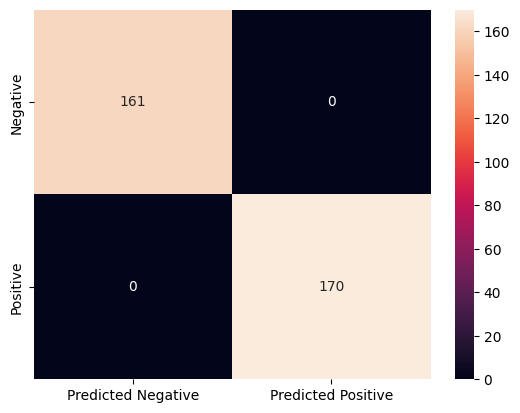

In [1109]:
plot_confusion_matrix(y, y_pred_train)

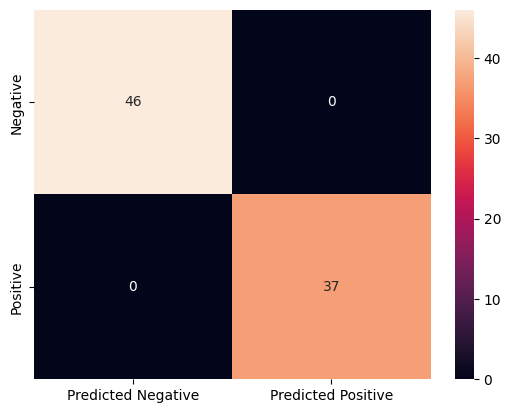

In [1110]:
plot_confusion_matrix(y_test, y_pred_test)

Testiamo il modello su due frasi esterne al dataset: una positiva e una negativa

In [1111]:
positive_sentence_list = [
    "Financial markets are performing well, driven by strong investor confidence and positive economic growth."
    "Financial markets are performing strongly.",
    "Investor confidence is increasing.",
    "Stock prices are rising steadily.",
    "The market is showing positive momentum.",
    "Investors are optimistic about economic growth.",
    "Companies are reporting strong earnings.",
    "Market conditions are improving.",
    "The economy is supporting higher stock valuations.",
    "Investors are showing strong demand for equities.",
    "Financial markets are benefiting from lower interest rates."
]

In [1112]:
negative_sentence_list = [
    "Financial markets are under pressure.",
    "Investor confidence is declining.",
    "Stock prices are falling sharply.",
    "The market is experiencing high volatility.",
    "Investors are concerned about economic uncertainty.",
    "Companies are reporting weaker-than-expected earnings.",
    "Market conditions are deteriorating.",
    "Rising interest rates are putting pressure on stocks.",
    "Investors are becoming more cautious.",
    "Financial markets are reacting negatively to inflation concerns."
    "Financial markets are facing uncertainty, with investors worried about inflation, rising interest rates, and economic slowdown."
]

In [1113]:
#definiamo una funzione per la verifica degli errori
def verifica_errori(risultati,v_confronto):
  n_errori = 0
  for i in risultati:
    if i != v_confronto:
      n_errori += 1

  return n_errori

In [1114]:
predict1 = clf.predict(bow_tfidf(data_cleaner(positive_sentence_list),vectorizer)[0])
predict_proba1 = clf.predict_proba(bow_tfidf(data_cleaner(positive_sentence_list),vectorizer)[0])

print(predict1)
print(predict_proba1)

errori1 = verifica_errori(predict1,"positive")
print(f"Numero errori: {errori1} ({(errori1/len(predict1)): .2f}% )")

['positive' 'negative' 'positive' 'positive' 'negative' 'positive'
 'positive' 'positive' 'positive' 'positive']
[[0.11247727 0.88752273]
 [0.77920874 0.22079126]
 [0.09596436 0.90403564]
 [0.10554586 0.89445414]
 [0.77920874 0.22079126]
 [0.1742629  0.8257371 ]
 [0.38133911 0.61866089]
 [0.34180801 0.65819199]
 [0.20766838 0.79233162]
 [0.38133911 0.61866089]]
Numero errori: 2 ( 0.20% )


In [1115]:
predict2 = clf.predict(bow_tfidf(data_cleaner(negative_sentence_list),vectorizer)[0])
predict_proba2 = clf.predict_proba(bow_tfidf(data_cleaner(negative_sentence_list),vectorizer)[0])

print(predict2)
print(predict_proba2)

errori2 = verifica_errori(predict2,"negative")
print(f"Numero errori: {errori2} ({(errori2/len(predict1)): .2f}% )")

['positive' 'negative' 'positive' 'positive' 'negative' 'negative'
 'positive' 'positive' 'negative' 'negative']
[[0.38133911 0.61866089]
 [0.92401389 0.07598611]
 [0.09596436 0.90403564]
 [0.38133911 0.61866089]
 [0.77920874 0.22079126]
 [0.82792162 0.17207838]
 [0.38133911 0.61866089]
 [0.34180801 0.65819199]
 [0.77920874 0.22079126]
 [0.80590779 0.19409221]]
Numero errori: 5 ( 0.50% )


##**PARTE 1: CONCLUSIONE**:

Come già anticipato, il modello potrebbe essere caratterizzato da overfitting o data lakeage.

Dall'**analisi delle metriche** non possiamo concludere che il modello si effettivamente caratterizzato da overfitting in quanto i risultati  per il training set e  per il test set sono simili: </br></br>

*Training Test Result*:

Log Loss: 0.108 </br>
Accuracy: 0.937 </br>
Precision: 0.890 </br>
Recall: 1.000 </br>
f1_score: 0.942 </br>
ROC_AUC: 1.000 </br></br>

*Testing Test Result*:

Log Loss: 0.119</br>
Accuracy: 0.916</br>
Precision: 0.841</br>
Recall: 1.000</br>
f1_score: 0.914</br>
ROC_AUC: 1.000</br></br>

 Si noti, in particolare, la **matrice di confusione** in cui il modello non genera falsi positivi o negativi sia per il training dataset e sia per il testing dataset. Pertanto è più probabile che siamo difronte ad un problema di data lakeage, ossia i dataset training e testing non sono indipendenti a causa della presenza di frasi molto simili tra loro.

D'altra parte, osservando i risultati su frasi non contenute nel dataset, si nota una maggior tendenza del modello ad attribuire un sentiment positivo quando in realtà la frase è negativa. Ciò è indice del fatto che il modello non è ancora pronto per essere generalizzato.

**Cause**:

- Frasi molto simili tra loro;
- Dizionario troppo piccolo;
- Eliminazione di parole rilevanti durante il pre-processing;
- Elevanta frequenza di parole specifiche

**Possibile soluzione al problema**:

Durante la fase di data cleaning vengono eliminate stop word che per tale contesto possono essere molto rilevanti (es. not, isn't, ecc.). </br>
Si potrebbero eliminare quelle parole la cui frequenza è elevata e la loro differenza di peso tra sentiment negativo e positivo è molto bassa, in modo evitare che determinate frasi siano altamente influenzate da queste ultime e riditribuire in modo più efficiente i pesi di ciascuna parola. </br>
Infine potrebbe essere opportuno utilizzare ngrammi (es. bigrammi) durate la fase di Vettorizzazione in modo da poter contestualizzare e pondedrare in modo più efficace il peso ed significato delle parole.

#PARTE 2

Proviamo adesso ad applicare le soluzioni consigliate dopo l'analisi del primo modello

In [1116]:
#creiamo una lista delle parole da non includere nelle stop word
words_to_remove = ["aren't","couldn't","didn","didn't","doesn","doesn't","don","don't","down","few","hadn","hadn't",
                   "hasn","hasn't","haven","haven't","isn't","not","up","wasn't","weren't","won't","isn",'mightn',
                   "mightn't",'mustn',"mustn't",'needn',"needn't",'wouldn',"wouldn't",'no','over']

len(words_to_remove)

33

In [1117]:
#eliminiamo dalla lista originaria le stopwords non desiderate
stop_words = english_stopwords.copy()

stop_words = [word for word in english_stopwords if word not in words_to_remove]

stop_words.append("market")
stop_words.append("financetech")

print(len(english_stopwords))
print(len(stop_words))
print(stop_words)

198
167
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', 'd', 'did', 'do', 'does', 'doing', 'during', 'each', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'nor', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'own', 're', 's', 'same', 'shan', "shan't", 'she', "she'd", "she'll", "she's", 'should', 'shouldn', "shouldn't", "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'then', 'there', 'these', 'they', "they'd", "they'll", "th

In [1118]:
#ridefiniamo la funzione includendo la nuova lista di stopwords
nlp = spacy.load("en_core_web_sm")
punctuation = set(string.punctuation)

def data_cleaner2(dataset):
  dataset_to_return = []
  for sentence in dataset:
    sentence = sentence.lower()
    for c in string.punctuation:
      sentence = sentence.replace(c, " ")
    document = nlp(sentence)
    sentence = " ".join(token.lemma_ for token in document)
    sentence = " ".join(word for word in sentence.split() if word not in stop_words)
    sentence = re.sub("\d", "", sentence)
    dataset_to_return.append(sentence)

  return dataset_to_return

<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1328/257384605.py:14: SyntaxWarning: invalid escape sequence '\d'
  sentence = re.sub("\d", "", sentence)


In [1119]:
#puliamo il dataset tweets
tweets_cleaned2 = data_cleaner2(tweets)

In [1120]:
tweets_cleaned2

['corp highlight drop stock value',
 'team announce record break profit',
 'investor thrill strong quarterly earning',
 'team disappoint decline profit',
 'corp announce positive customer feedback',
 'shareholder face decline profit',
 'team announce strong quarterly earning',
 'corp highlight contraction',
 'shareholder face negative investor sentiment',
 'investor announce record break profit',
 'investor highlight negative investor sentiment',
 'team announce negative investor sentiment',
 'analyst enjoy record break profit',
 'investor report expansion',
 'corp highlight positive customer feedback',
 'analyst disappoint drop stock value',
 'team struggle negative investor sentiment',
 'team highlight decline profit',
 'corp report expansion',
 'analyst announce record break profit',
 'shareholder report weak earning',
 'ceo report weak earning',
 'analyst enjoy strong quarterly earning',
 'corp disappoint drop stock value',
 'investor highlight expansion',
 'team thrill record brea

In [1121]:
#verifichiamo che la lunghezza corrisponda al dataset iniziale
if len(tweets_cleaned2)==len(tweets):
  print(f"Le lunghezze corrispondono: {len(tweets_cleaned)}, {len(tweets)}")
else:
  print(f"ERRORE. Le lunghezze non corrispondono: {len(tweets_cleaned)}, {len(tweets)}")

Le lunghezze corrispondono: 414, 414


Vettorizzazione

In [1122]:
#splittiamo il dataset pulito utilizzando train_test_split
xx, xx_test, yy, yy_test = train_test_split(tweets_cleaned2, sentiments, test_size = 0.2, random_state = 46)

In [1123]:
#ridefiniamo la funzione per applicare il metodo TF-IDF
def bow_tfidf2(dataset, tfidf_vectorizer):
  if tfidf_vectorizer == None:
    tfidf_vectorizer = TfidfVectorizer(min_df=0.01, max_df=0.8, ngram_range=(1, 2))
    X = tfidf_vectorizer.fit_transform(dataset)
  else:
    X = tfidf_vectorizer.transform(dataset)

  return X.toarray(), tfidf_vectorizer

In [1124]:
#applichiamo il metodo TF-IDF al training dataset
training_dataset_2, vectorizer_2 = bow_tfidf2(xx,None)

In [1125]:
#applichiamo il metodo TF-IDF al testing dataset
testing_dataset_2, vectorizer_2 = bow_tfidf2(xx_test,vectorizer_2)

testing_dataset

array([[0.        , 0.44320902, 0.        , ..., 0.        , 0.        ,
        0.58273348],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.43280583, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.47543208, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.37747186, 0.36800009, 0.51395432, ..., 0.        , 0.        ,
        0.        ]])

Analizziamo il dizionario

In [1126]:
print(vectorizer_2.get_feature_names_out())
print(vectorizer_2.vocabulary_)

['analyst' 'analyst announce' 'analyst celebrate' 'analyst disappoint'
 'analyst enjoy' 'analyst face' 'analyst highlight' 'analyst report'
 'analyst struggle' 'announce' 'announce contraction' 'announce decline'
 'announce drop' 'announce expansion' 'announce fail' 'announce negative'
 'announce positive' 'announce record' 'announce strong'
 'announce successful' 'announce surge' 'break' 'break profit' 'breaking'
 'breaking profit' 'celebrate' 'celebrate positive' 'celebrate record'
 'celebrate surge' 'ceo' 'ceo announce' 'ceo celebrate' 'ceo enjoy'
 'ceo face' 'ceo highlight' 'ceo report' 'ceo struggle' 'ceo thrill'
 'contraction' 'corp' 'corp announce' 'corp celebrate' 'corp disappoint'
 'corp enjoy' 'corp face' 'corp highlight' 'corp report' 'corp struggle'
 'corp thrill' 'customer' 'customer feedback' 'decline' 'decline profit'
 'disappoint' 'disappoint contraction' 'disappoint decline'
 'disappoint drop' 'disappoint fail' 'disappoint negative' 'drop'
 'drop stock' 'earning' 'enjo

In [1127]:
len(vectorizer_2.vocabulary_)

167

In [1128]:
features_2 = vectorizer_2.get_feature_names_out()
word_frequencies_2 = {}

for f in features_2:
    count = 0

    for tweet in tweets_cleaned2:
        tokens = tweet.split()

        # singola parola
        if " " not in f:
            count += tokens.count(f)

        # bigrammi
        else:
            bigram_count = sum(
                1 for i in range(len(tokens) - 1)
                if tokens[i] + " " + tokens[i + 1] == f
            )
            count += bigram_count

    word_frequencies_2[f] = count

# Ordiniamo per frequenza decrescente
sorted_word_frequencies_2 = sorted(
    word_frequencies_2.items(),
    key=lambda item: item[1],
    reverse=True
)

print("Frequenze delle parole e dei bigrammi:")

for word, freq in sorted_word_frequencies_2:
    print(f"  {word}: {freq}")

Frequenze delle parole e dei bigrammi:
  investor: 103
  team: 72
  launch: 71
  product: 71
  product launch: 71
  corp: 70
  report: 70
  stock: 70
  ceo: 69
  profit: 69
  analyst: 68
  announce: 68
  earning: 67
  highlight: 67
  shareholder: 66
  enjoy: 36
  price: 36
  record: 36
  stock price: 36
  successful: 36
  successful product: 36
  surge: 36
  surge stock: 36
  thrill: 36
  weak: 36
  weak earning: 36
  contraction: 35
  disappoint: 35
  face: 35
  fail: 35
  fail product: 35
  struggle: 35
  customer: 34
  customer feedback: 34
  drop: 34
  drop stock: 34
  expansion: 34
  feedback: 34
  investor sentiment: 34
  negative: 34
  negative investor: 34
  positive: 34
  positive customer: 34
  sentiment: 34
  stock value: 34
  value: 34
  decline: 33
  decline profit: 33
  celebrate: 32
  quarterly: 31
  quarterly earning: 31
  strong: 31
  strong quarterly: 31
  break: 25
  break profit: 25
  record break: 25
  analyst report: 12
  ceo highlight: 12
  ceo report: 12
  corp 

In [1129]:
# Creiamo un DataFrame per analizzare i pesi TF-IDF in relazione al sentiment
training_df_2 = pd.DataFrame(training_dataset_2, columns=features_2)
training_df_2['sentiment'] = yy.reset_index(drop=True)

# Calcoliamo il TF-IDF medio per le parole con sentiment 'positive'
positive_sentiment_weights_2 = training_df_2[training_df_2['sentiment'] == 'positive'].drop(columns=['sentiment']).mean().sort_values(ascending=False)

# Calcoliamo il TF-IDF medio per le parole con sentiment 'negative'
negative_sentiment_weights_2 = training_df_2[training_df_2['sentiment'] == 'negative'].drop(columns=['sentiment']).mean().sort_values(ascending=False)

print("Peso delle parole per sentiment POSITIVO:")
print(positive_sentiment_weights_2)
print("\nPeso delle parole per sentiment NEGATIVO:")
print(negative_sentiment_weights_2)

Peso delle parole per sentiment POSITIVO:
expansion        0.072654
surge            0.061953
price            0.061953
stock price      0.061953
surge stock      0.061953
                   ...   
team face        0.000000
team struggle    0.000000
value            0.000000
weak             0.000000
weak earning     0.000000
Length: 166, dtype: float64

Peso delle parole per sentiment NEGATIVO:
investor             0.080061
contraction          0.067966
face                 0.063756
fail product         0.063501
fail                 0.063501
                       ...   
thrill positive      0.000000
thrill successful    0.000000
thrill strong        0.000000
thrill record        0.000000
thrill surge         0.000000
Length: 166, dtype: float64


Addestriamo il modello e calcoliamo le metriche

In [1130]:
clf.fit(training_dataset_2, yy)

Iteration 1, loss = 0.70606500
Iteration 2, loss = 0.68842072
Iteration 3, loss = 0.67231952
Iteration 4, loss = 0.66287135
Iteration 5, loss = 0.65303249
Iteration 6, loss = 0.64443871
Iteration 7, loss = 0.63504134
Iteration 8, loss = 0.62529270
Iteration 9, loss = 0.61665399
Iteration 10, loss = 0.60665712
Iteration 11, loss = 0.59757629
Iteration 12, loss = 0.58689605
Iteration 13, loss = 0.57786418
Iteration 14, loss = 0.56730706
Iteration 15, loss = 0.55567941
Iteration 16, loss = 0.54534177
Iteration 17, loss = 0.53332037
Iteration 18, loss = 0.52179443
Iteration 19, loss = 0.50995959
Iteration 20, loss = 0.49717532
Iteration 21, loss = 0.48491100
Iteration 22, loss = 0.47333834
Iteration 23, loss = 0.45886350
Iteration 24, loss = 0.44479899
Iteration 25, loss = 0.43103763
Iteration 26, loss = 0.41765792
Iteration 27, loss = 0.40279898
Iteration 28, loss = 0.38880444
Iteration 29, loss = 0.37483245
Iteration 30, loss = 0.36107847
Iteration 31, loss = 0.34597912
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=(1000,), max_iter=100,
              tol=0.005, verbose=True)

In [1131]:
#Verifichiamo l'accuratezza del modello
clf.score(testing_dataset_2,yy_test)

1.0

In [1132]:
#fittiamo l'encoder sulle classi del modello (positve e negative)
le.fit(clf.classes_)

# Codifica le etichette vere 'y' in valori numerici usando l'encoder addestrato
yy_encoded_train = le.transform(yy)

evaluate_model(clf,(training_dataset_2, yy_encoded_train),0.2)


Log Loss: 0.061
Accuracy: 0.997
Precision: 0.994
Recall: 1.000
f1_score: 0.997
ROC_AUC: 1.000


In [1133]:
yy_encoded_test = le.transform(yy_test)

In [1134]:
evaluate_model(clf,(testing_dataset_2, yy_encoded_test),0.2)

Log Loss: 0.094
Accuracy: 0.940
Precision: 0.881
Recall: 1.000
f1_score: 0.937
ROC_AUC: 1.000


In [1135]:
yy_pred_train = clf.predict(training_dataset_2)
yy_pred_test = clf.predict(testing_dataset_2)

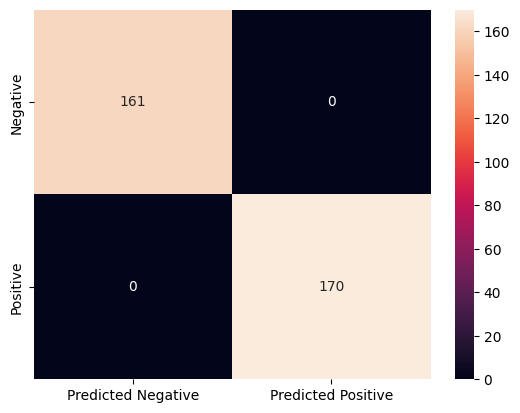

In [1136]:
plot_confusion_matrix(yy, yy_pred_train)

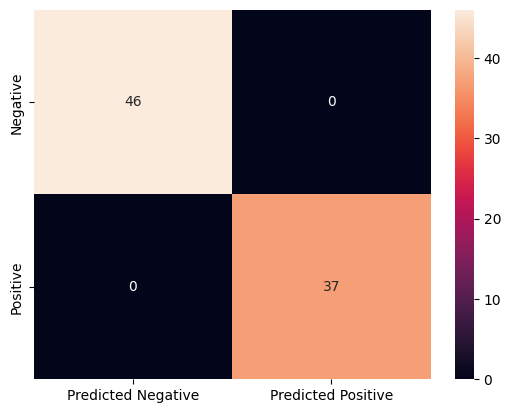

In [1137]:
plot_confusion_matrix(yy_test, yy_pred_test)

In [1138]:
predict1 = clf.predict(bow_tfidf2(data_cleaner2(positive_sentence_list),vectorizer_2)[0])
predict_proba1 = clf.predict_proba(bow_tfidf2(data_cleaner2(positive_sentence_list),vectorizer_2)[0])

print(predict1)
print(predict_proba1)

errori1 = verifica_errori(predict1,"positive")
print(f"Numero errori: {errori1} ({(errori1/len(predict1)): .2f}% )")

['positive' 'negative' 'positive' 'positive' 'negative' 'positive'
 'positive' 'positive' 'positive' 'positive']
[[0.17292615 0.82707385]
 [0.77723843 0.22276157]
 [0.08790375 0.91209625]
 [0.15984538 0.84015462]
 [0.77723843 0.22276157]
 [0.15099288 0.84900712]
 [0.47588689 0.52411311]
 [0.35694553 0.64305447]
 [0.32845974 0.67154026]
 [0.47588689 0.52411311]]
Numero errori: 2 ( 0.20% )


In [1139]:
predict2 = clf.predict(bow_tfidf2(data_cleaner2(negative_sentence_list),vectorizer_2)[0])
predict_proba2 = clf.predict_proba(bow_tfidf2(data_cleaner2(negative_sentence_list),vectorizer_2)[0])


print(predict2)
print(predict_proba2)

errori2 = verifica_errori(predict2,"negative")
print(f"Numero errori: {errori2} ({(errori2/len(predict1)): .2f}% )")

['positive' 'negative' 'positive' 'positive' 'negative' 'negative'
 'positive' 'positive' 'negative' 'negative']
[[0.47588689 0.52411311]
 [0.895887   0.104113  ]
 [0.08790375 0.91209625]
 [0.47588689 0.52411311]
 [0.77723843 0.22276157]
 [0.90348098 0.09651902]
 [0.47588689 0.52411311]
 [0.35694553 0.64305447]
 [0.77723843 0.22276157]
 [0.88193574 0.11806426]]
Numero errori: 5 ( 0.50% )


#**CONCLUSIONE**
Nonostante abbiamo utilizzato come stopwords i termini "financetech" e "market" ed eliminato specfiche parole dalla lista in modo da rafforzare i risultati negativi ed utilizzato bigrammi non abbiamo ottenuto alcun miglioramento del modello.

Al contrario, i risultati sul test set sono lievemente peggiorati:

*Training Result*:

Log Loss: 0.062</br>
Accuracy: 0.997</br>
Precision: 0.994</br>
Recall: 1.000</br>
f1_score: 0.997</br>
ROC_AUC: 1.000</br></br>

*Testing result*:

Log Loss: 0.099</br>
Accuracy: 0.928</br>
Precision: 0.860</br>
Recall: 1.000</br>
f1_score: 0.925</br>
ROC_AUC: 1.000</br></br>

Tali risultati possono essere indice di overfitting.

Sulle stesse frasi esterne al dataset, il modello genera gli stessi errori.

La principale causa può essere dunque attribuita all'omogeneità del dataset che porta a sviluppare un dizionario poco efficiente per il contesto finanziario generale.